In [1]:
%cd /home/ytee/test/trade_bot/
# %matplotlib inline
# from src.pattern.range_market import MY_RANGE
import mplfinance as mpf
import numpy as np
import pandas as pd
from src.pattern.correlation import CORR3
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("TkAgg")     # or "Qt5Agg"
from tqdm import tqdm
import itertools

/home/ytee/test/trade_bot/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ytee/test/trade_bot


In [2]:
cr = CORR3(['AUD', "JPY", 'USD', 'GBP', 'CAD', 'CHF', 'EUR'], force_reset=True)
df = cr.get_all_pairs()
# cr.get_future()

In [3]:
feature_list = []

for i, c in tqdm(itertools.product(range(10, 1000, 10), df.columns),
                 total=len(range(10, 1000, 10)) * len(df.columns)):
    past = np.log(df[c] / df[c].shift(i))
    past.name =  f"{c}_logreturn_{i}d_p"
    future  = np.log(df[c].shift(-i) / df[c])
    future.name = f"{c}_logreturn_{i}d_f"
    feature_list.append(past)
    feature_list.append(future)
df_ret = pd.concat(feature_list, axis=1)


100%|██████████| 693/693 [00:00<00:00, 1119.89it/s]


<Axes: >

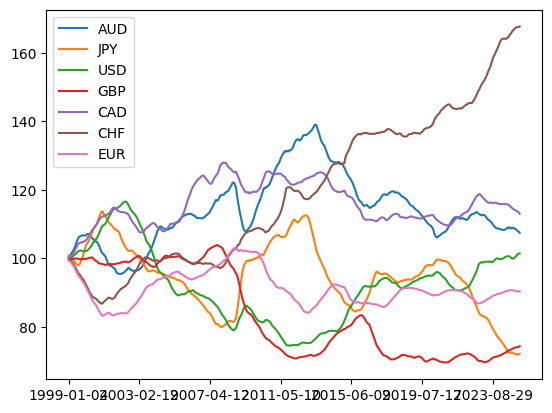

In [4]:
%matplotlib inline
ewm_df = df.ewm(halflife=100, adjust=False).mean()
ewm_df.plot()


In [23]:

def test(shift = 50, predict_period=10, verbose=False, raw=False):
    lbw_raw = df_ret[[ x for x in df_ret.columns if 'logreturn_%sd_p' % shift in x]]
    lbw = lbw_raw.sub(lbw_raw.max(axis=1), axis=0)
    lbw_ewm = lbw.copy()

    for c in lbw.columns:
        lbw_ewm[c] = lbw[c].ewm(halflife=shift, adjust=False).mean()
    fut= df_ret[[ x for x in df_ret.columns if 'logreturn_%sd_f' % predict_period in x]]
    # Flatten both
    flat1 = lbw_ewm.to_numpy().ravel()
    flat2 = fut.to_numpy().ravel()

    # Combine into 2-column DataFrame
    result = pd.DataFrame({
        "lbw_ewm": flat1,
        "ret": flat2
    })

    if raw:
        return result
    # ax = result.plot(kind="scatter", x="lbw", y="ret", title="Scatter Plot of Flattened DataFrames")
    result["lbw_bin"] = pd.cut(result["lbw_ewm"], bins=10)
    result["lbw2"] = result["lbw_bin"].apply(lambda x: x.mid)
    
    grouped = result.groupby("lbw2", observed=True)["ret"].mean()#.reset_index()
    x = grouped.index.to_numpy()
    y = grouped.values
    m, b = np.polyfit(x, y, 1)

    if verbose:
        print('shift:%s, predict_period: %s, gradient: %s' % (shift, predict_period, m))
    return m

    

<Axes: xlabel='lbw_ewm', ylabel='ret'>

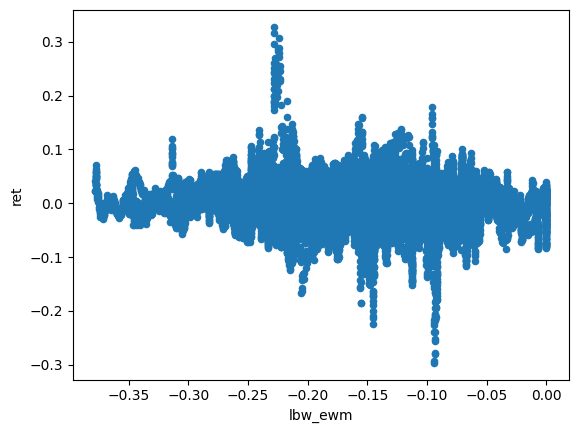

In [53]:
t1 = test(600, 50, raw=True)
t1.plot(kind='scatter', x= 'lbw_ewm', y='ret' )


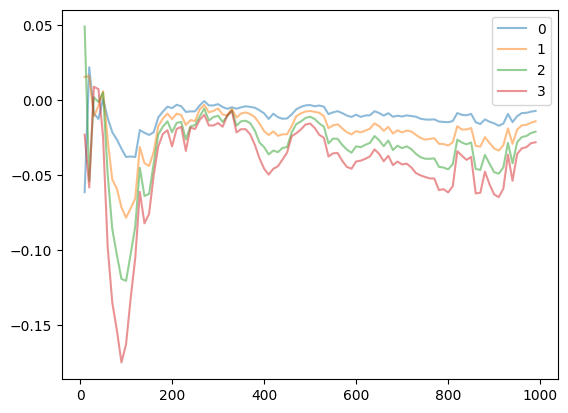

In [49]:

alldict = []
for i2 in range(10, 50, 10):
    data = {}
    for i in range(10, 1000, 10):
        data[i] = test(i, i2)

    aa = pd.DataFrame.from_dict(data, orient='index')
    alldict.append(aa)



cc = pd.concat(alldict, axis=1)
cc.columns = list(map(str, range(len(cc.columns))))


for c in cc.columns:
    ax = cc[c].plot(alpha=0.5, label=c)


ax.legend()



In [44]:

cc = pd.concat(alldict, axis=1)

['0', '1', '2', '3']